# 1. Download Gaze Fraction Sweeps (0.8, 0.9, 1.0)
This cell connects to W&B to fetch the data from the two new sweeps:
* `y1z4uig3`: Align mode (Raw and Rollout)
* `i8o6lfxo`: EGViT, Guide (GII Injection), and Disable (Off)

It extracts the `train_gaze_frac` parameter, as well as the test accuracy achieved at the best validation epoch.

In [1]:
import wandb
import pandas as pd
import numpy as np

# Setup API
api = wandb.Api()
entity = "luis-perdigao-instituto-superior-t-cnico"
project = "PCS_ET_v22"
target_sweeps = ["y1z4uig3", "i8o6lfxo"]

print(f"Connecting to {entity}/{project}...")

data_list = []

for sweep_id in target_sweeps:
    print(f"Fetching runs from sweep: {sweep_id}...")
    try:
        sweep = api.sweep(f"{entity}/{project}/{sweep_id}")
        runs = sweep.runs
    except Exception as e:
        print(f"Error accessing sweep {sweep_id}: {e}")
        continue

    print(f"  Found {len(runs)} runs. Scanning history...")

    for run in runs:
        config = {k: v for k, v in run.config.items() if not k.startswith('_')}
        
        # Fetch History
        keys = ["accuracy_validation", "accuracy_test"]
        history = pd.DataFrame(run.scan_history(keys=keys))
        
        test_rank_acc = np.nan
        
        if not history.empty and "accuracy_validation" in history.columns:
            best_epoch_idx = history["accuracy_validation"].idxmax()
            if "accuracy_test" in history.columns:
                test_rank_acc = history.loc[best_epoch_idx, "accuracy_test"]
        else:
            test_rank_acc = run.summary.get("max_accuracy_test", run.summary.get("accuracy_test", np.nan))

        # Extract specific parameters
        gaze_mode = config.get("gaze_mode", "off")
        attn_mode = config.get("attention_mode", "raw")
        
        # Determine method name
        g_mode_lower = str(gaze_mode).lower()
        if g_mode_lower == 'align':
            method_name = f"Align ({str(attn_mode).capitalize()})"
        elif g_mode_lower in ['off', 'disable']:
            method_name = "Baseline (Off)"
        elif g_mode_lower == 'guide':
            method_name = "Guide (GII Injection)"
        elif g_mode_lower == 'egvit':
            method_name = "EGViT"
        else:
            method_name = str(gaze_mode).capitalize()

        data_list.append({
            "run_name": run.name,
            "backbone": config.get("backbone", "unknown"),
            "gaze_method": method_name,
            "train_gaze_frac": config.get("train_gaze_frac", 1.0),
            "test_rank_acc": test_rank_acc * 100 if not np.isnan(test_rank_acc) else np.nan
        })

# Save to CSV
df_new = pd.DataFrame(data_list)
df_new.to_csv("gaze_frac_sweeps.csv", index=False)
print(f"Done! Saved {len(df_new)} runs to 'gaze_frac_sweeps.csv'.")

wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: luis-perdigao (luis-perdigao-instituto-superior-t-cnico) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Connecting to luis-perdigao-instituto-superior-t-cnico/PCS_ET_v22...
Fetching runs from sweep: y1z4uig3...
  Found 54 runs. Scanning history...
Fetching runs from sweep: i8o6lfxo...
  Found 54 runs. Scanning history...
Done! Saved 108 runs to 'gaze_frac_sweeps.csv'.


# 2. Integrate Data and Plot Gaze Percentage Impact
This cell performs the following:
1. Loads the newly swept data (`0.8`, `0.9`, `1.0`).
2. Integrates your previous `0.7` fraction data (hardcoded from your table).
3. Converts the `train_gaze_frac` to the actual percentage of the training set ($999 / 4134$).
4. Generates **5 separate plots** (one for each gaze method), displaying the 3 backbone curves on each.

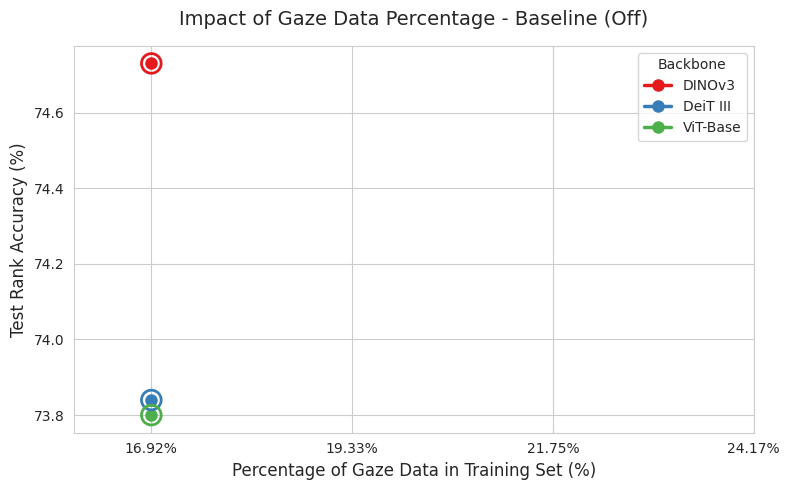

Saved: gaze_pct_Baseline_Off.png



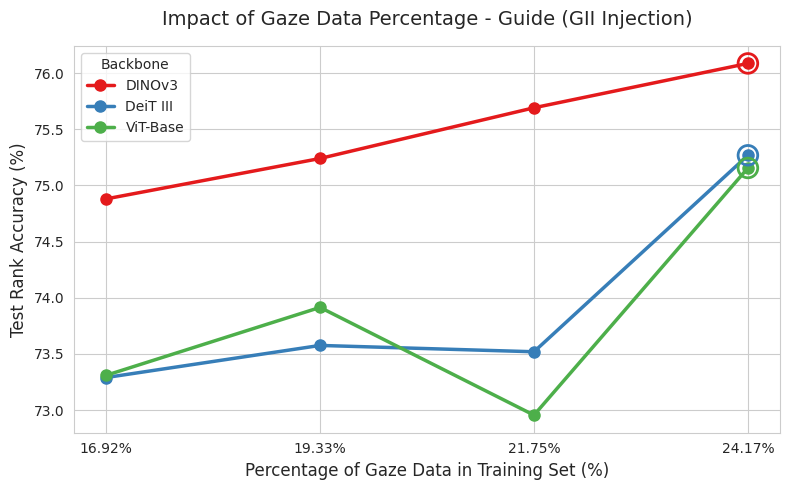

Saved: gaze_pct_Guide_GII_Injection.png



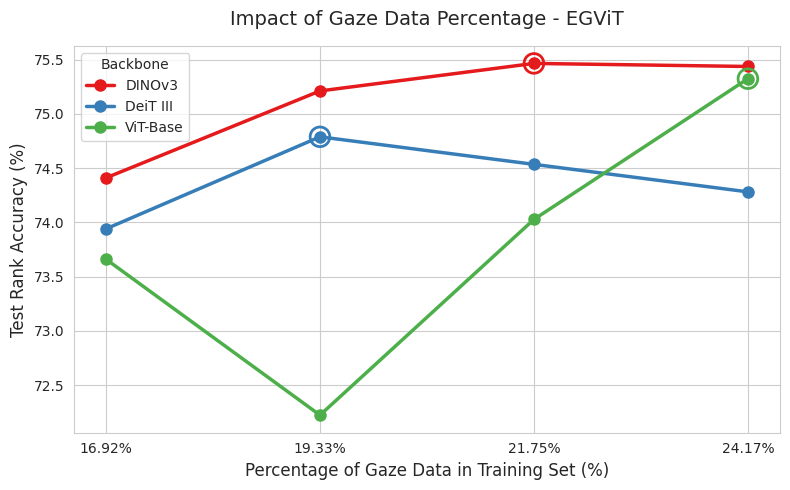

Saved: gaze_pct_EGViT.png



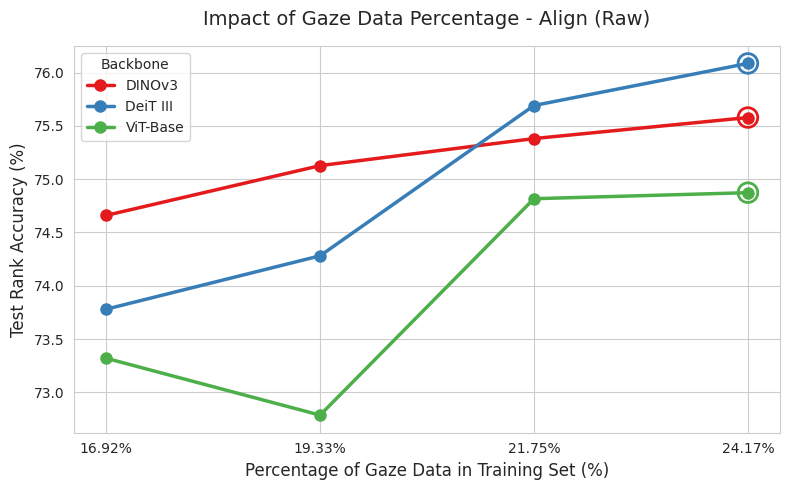

Saved: gaze_pct_Align_Raw.png



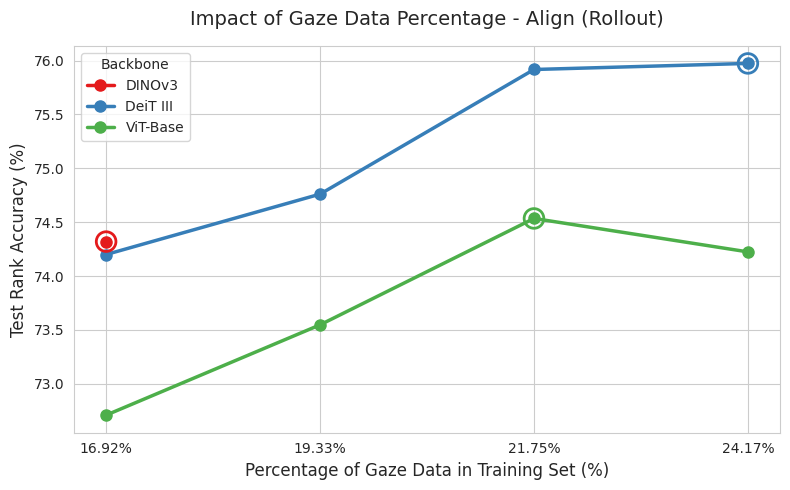

Saved: gaze_pct_Align_Rollout.png



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Base Data from previous 0.7 sweep (from user table)
# Structure: [DINOv3, DeiT III, ViT-Base]
base_data_07 = {
    "Baseline (Off)": [74.73, 73.84, 73.80],
    "Guide (GII Injection)": [74.88, 73.29, 73.31],
    "EGViT": [74.41, 73.94, 73.66],
    "Align (Raw)": [74.66, 73.78, 73.32],
    "Align (Rollout)": [74.32, 74.20, 72.71]
}
backbones = ["DINOv3", "DeiT III", "ViT-Base"]

records_07 = []
for method, scores in base_data_07.items():
    for bb, score in zip(backbones, scores):
        records_07.append({
            "backbone": bb,
            "gaze_method": method,
            "train_gaze_frac": 0.7,
            "test_rank_acc": score
        })

df_07 = pd.DataFrame(records_07)

# 2. Load New Data (0.8, 0.9, 1.0)
try:
    df_new = pd.read_csv("gaze_frac_sweeps.csv")
    # Clean backbone names
    bb_map = {
        'dinov3_vitb16': 'DINOv3',
        'vit_base_patch16_224': 'ViT-Base',
        'deit3_base_patch16_224': 'DeiT III'
    }
    df_new['backbone'] = df_new['backbone'].map(bb_map).fillna(df_new['backbone'])
    
    # Aggregate over seeds (mean)
    df_new_agg = df_new.groupby(['backbone', 'gaze_method', 'train_gaze_frac'], as_index=False)['test_rank_acc'].mean()
    
except FileNotFoundError:
    print("New sweep data not found. Plotting only 0.7 data.")
    df_new_agg = pd.DataFrame()

# 3. Combine Datasets
df_combined = pd.concat([df_07, df_new_agg], ignore_index=True)

# 4. Convert fraction to real percentage
# 999 maximum gaze comparisons out of 4134 total training data
def calc_real_percentage(frac):
    return (frac * 999) / 4134 * 100

df_combined['real_gaze_pct'] = df_combined['train_gaze_frac'].apply(calc_real_percentage)

# 5. Generate 5 Plots
gaze_methods = df_combined['gaze_method'].unique()
colors = sns.color_palette("Set1", len(backbones))

sns.set_style("whitegrid")

for method in gaze_methods:
    plt.figure(figsize=(8, 5))
    df_method = df_combined[df_combined['gaze_method'] == method]
    
    # Plot each backbone
    for i, bb in enumerate(backbones):
        df_plot = df_method[df_method['backbone'] == bb].sort_values('real_gaze_pct')
        
        if not df_plot.empty:
            plt.plot(df_plot['real_gaze_pct'], df_plot['test_rank_acc'], 
                     marker='o', markersize=8, linewidth=2.5, 
                     color=colors[i], label=bb)
            
            # Optional: Annotate the max point for each line
            best_idx = df_plot['test_rank_acc'].idxmax()
            best_row = df_plot.loc[best_idx]
            plt.scatter(best_row['real_gaze_pct'], best_row['test_rank_acc'], 
                        color='none', edgecolor=colors[i], s=200, zorder=5, linewidths=2)

    # Formatting
    plt.title(f"Impact of Gaze Data Percentage - {method}", fontsize=14, pad=15)
    plt.xlabel("Percentage of Gaze Data in Training Set (%)", fontsize=12)
    plt.ylabel("Test Rank Accuracy (%)", fontsize=12)
    
    # Customizing X-Ticks to show exactly where the fractions land
    # 0.7 ~ 16.91%, 0.8 ~ 19.33%, 0.9 ~ 21.75%, 1.0 ~ 24.17%
    x_ticks = [calc_real_percentage(f) for f in [0.7, 0.8, 0.9, 1.0]]
    x_labels = [f"{x:.2f}%" for x in x_ticks]
    plt.xticks(x_ticks, x_labels)

    plt.legend(title="Backbone", loc="best")
    plt.tight_layout()
    
    # Save image
    safe_name = method.replace(" ", "_").replace("(", "").replace(")", "")
    file_name = f"gaze_pct_{safe_name}.png"
    plt.savefig(file_name, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved: {file_name}\n")